Lab Exercise 3: Simple Linear Regression using Scikit-Learn, OLS, and Parameter Saving

In [25]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

Part A: Data Collection, Export, and Initial Preprocessing

In [26]:
df_excel = pd.read_excel("Department Awareness Survey (Responses).xlsx")
df_excel.to_csv("student_survey.csv", index=False)
df = pd.read_csv("student_survey.csv")

print("Dataset dimensions:", df.shape)
print("\nFirst 5 Rows of raw dataset:")
df.head(5)

Dataset dimensions: (54, 15)

First 5 Rows of raw dataset:


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [27]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate records:", df.duplicated().sum())

Missing values per column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your

In [28]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

In [29]:
numeric_cols = [
    "What is the minimum salary of students placed through campus (In LPA..respond as a number)",
    "What is the maximum salary of students placed through campus (In LPA..respond as a number)",
    "What is the median salary of students placed through campus (In LPA..respond as a number)",
    "What are your package expectations (LPA)",
    "your CIA % of last semester",
    "your GPA of last semester",
    "Your maximum attendance % till last semester"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

In [30]:
print(df.isnull().sum())

Timestamp                                                                                      0
Registration Number                                                                            0
Email                                                                                          0
Job role that you are interested in                                                            0
What is the minimum salary of students placed through campus (In LPA..respond as a number)     8
What is the maximum salary of students placed through campus (In LPA..respond as a number)    15
What is the median salary of students placed through campus (In LPA..respond as a number)      7
Which is the highest paying company                                                            0
Rate your contribution towards extra curricular activities                                     0
Rate your technical competencies                                                               0
What are your package expectat

Filling What is the minimum salary of students placed through campus (In LPA..respond as a number), What is the maximum salary of students placed through campus (In LPA..respond as a number), What is the median salary of students placed through campus (In LPA..respond as a number) with meadian as thats the most appropriate one.

FOr CIA & GPA, median was used because there was only one missing value, preserving the dataset while minimizing distortion.

for attendance, mode was used because the missing values originated from invalid categorical responses ("Option 1"), and the most frequent attendance value is the most representative replacement

In [31]:
salary_cols = [
    "What is the minimum salary of students placed through campus (In LPA..respond as a number)",
    "What is the maximum salary of students placed through campus (In LPA..respond as a number)",
    "What is the median salary of students placed through campus (In LPA..respond as a number)",
    "What are your package expectations (LPA)"
]

for col in salary_cols:
    df[col].fillna(df[col].median(), inplace=True)

df["your CIA % of last semester"].fillna(
    df["your CIA % of last semester"].median(),
    inplace=True
)

df["your GPA of last semester"].fillna(
    df["your GPA of last semester"].median(),
    inplace=True
)

df["Your maximum attendance % till last semester"].fillna(
    df["Your maximum attendance % till last semester"].mode()[0],
    inplace=True
)

In [32]:
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [33]:
cols = [
    "your CIA % of last semester",
    "your GPA of last semester",
    "Your maximum attendance % till last semester"
]

df_clean = df[cols].copy()

df_clean.columns = [
    "CIA_Percentage",
    "GPA",
    "Attendance_Percentage"
]

df_clean = df_clean[(df_clean["CIA_Percentage"] >= 40)]
df_clean = df_clean[(df_clean["Attendance_Percentage"] >= 50)]
df_clean = df_clean[(df_clean["GPA"] >= 0) & (df_clean["GPA"] <= 4)]
print("\nCleaned Statistical Summary:")

print(df_clean.describe())



Cleaned Statistical Summary:
       CIA_Percentage        GPA  Attendance_Percentage
count       41.000000  41.000000              41.000000
mean        73.478049   3.445610              93.365366
std          6.134103   0.251854               4.400008
min         60.000000   2.900000              85.000000
25%         70.000000   3.300000              90.000000
50%         71.000000   3.460000              95.000000
75%         78.000000   3.600000              97.000000
max         89.000000   3.890000             100.000000


Invalid categorical entries in numeric columns were converted to NaN and handled using appropriate imputation techniques. Numeric columns were cleaned, duplicates were removed, and the dataset was transformed into a consistent format suitable for regression analysis.

Visualizing Data Distributions
To check the distributions of our cleaned independent and dependent variables, we plot their probability density distributions.

c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


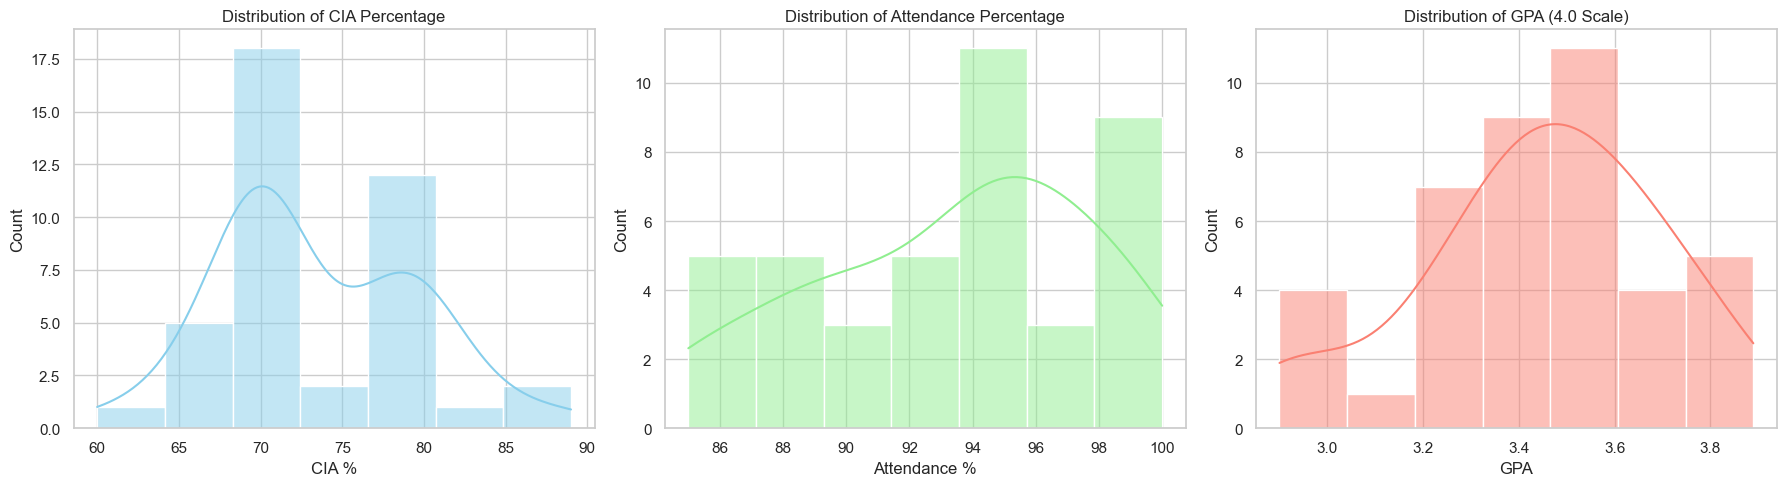

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean['CIA_Percentage'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of CIA Percentage')
axes[0].set_xlabel('CIA %')
sns.histplot(df_clean['Attendance_Percentage'], kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of Attendance Percentage')
axes[1].set_xlabel('Attendance %')
sns.histplot(df_clean['GPA'], kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Distribution of GPA (4.0 Scale)')
axes[2].set_xlabel('GPA')

plt.tight_layout()
plt.show()

Experiment 1

In [35]:
print("Independent Variable (X): CIA Percentage")
print("Dependent Variable (Y): GPA")

X_cia = df_clean[["CIA_Percentage"]]
y = df_clean["GPA"]

print(X_cia.head())
print(y.head())

Independent Variable (X): CIA Percentage
Dependent Variable (Y): GPA
   CIA_Percentage
0           78.00
1           64.78
2           80.00
3           70.00
4           68.00
0    3.24
1    3.20
2    3.60
3    3.20
4    3.40
Name: GPA, dtype: float64


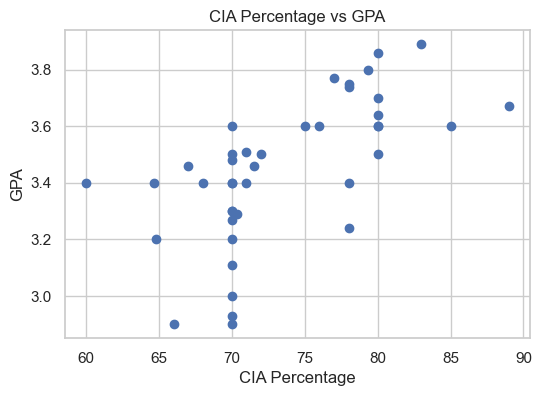

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean["CIA_Percentage"], df_clean["GPA"])
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA Percentage vs GPA")
plt.show()

Experiment 2

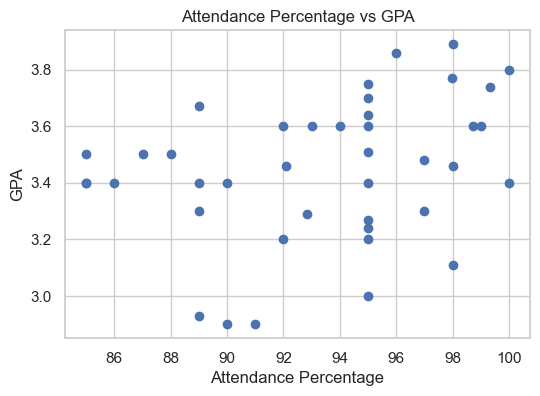

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean["Attendance_Percentage"], df_clean["GPA"])
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance Percentage vs GPA")
plt.show()

In [38]:
print(df_clean.corr(numeric_only=True))

                       CIA_Percentage       GPA  Attendance_Percentage
CIA_Percentage               1.000000  0.630898               0.358673
GPA                          0.630898  1.000000               0.307616
Attendance_Percentage        0.358673  0.307616               1.000000


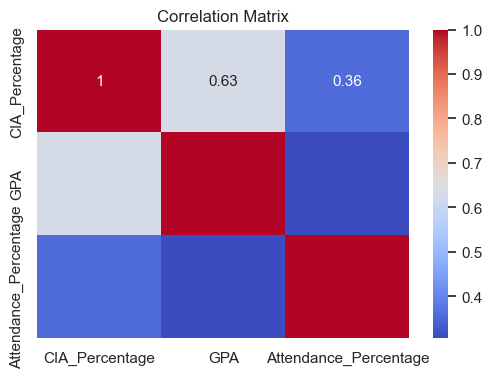

In [39]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Part B: Simple Linear Regression using Scikit-Learn

In [40]:
X_cia = df_clean[['CIA_Percentage']].values
X_att = df_clean[['Attendance_Percentage']].values
y = df_clean['GPA'].values


X_cia_train, X_cia_test, y_train, y_test = train_test_split(
    X_cia, y, test_size=0.2, random_state=42
)
X_att_train, X_att_test, _, _ = train_test_split(
    X_att, y, test_size=0.2, random_state=42
)

# Experiment 1: CIA % vs GPA
model_cia = LinearRegression()
model_cia.fit(X_cia_train, y_train)
y_pred_cia_sk = model_cia.predict(X_cia_test)
slope_cia_sk = model_cia.coef_[0]
intercept_cia_sk = model_cia.intercept_

# Experiment 2: Attendance % vs GPA
model_att = LinearRegression()
model_att.fit(X_att_train, y_train)
y_pred_att_sk = model_att.predict(X_att_test)
slope_att_sk = model_att.coef_[0]
intercept_att_sk = model_att.intercept_

print("CIA % vs GPA (Scikit-Learn)")
print(f"Slope (beta_1): {slope_cia_sk:.6f}")
print(f"Intercept (beta_0): {intercept_cia_sk:.6f}")
print(f"R² Score: {r2_score(y_test, y_pred_cia_sk):.6f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_cia_sk):.6f}")

print("\nAttendance % vs GPA (Scikit-Learn)")
print(f"Slope (beta_1): {slope_att_sk:.6f}")
print(f"Intercept (beta_0): {intercept_att_sk:.6f}")
print(f"R² Score: {r2_score(y_test, y_pred_att_sk):.6f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_att_sk):.6f}")

CIA % vs GPA (Scikit-Learn)
Slope (beta_1): 0.028338
Intercept (beta_0): 1.342532
R² Score: 0.073031
MSE: 0.047511

Attendance % vs GPA (Scikit-Learn)
Slope (beta_1): 0.015515
Intercept (beta_0): 1.982574
R² Score: 0.205465
MSE: 0.040723


Visualizing Fitted Regression Lines


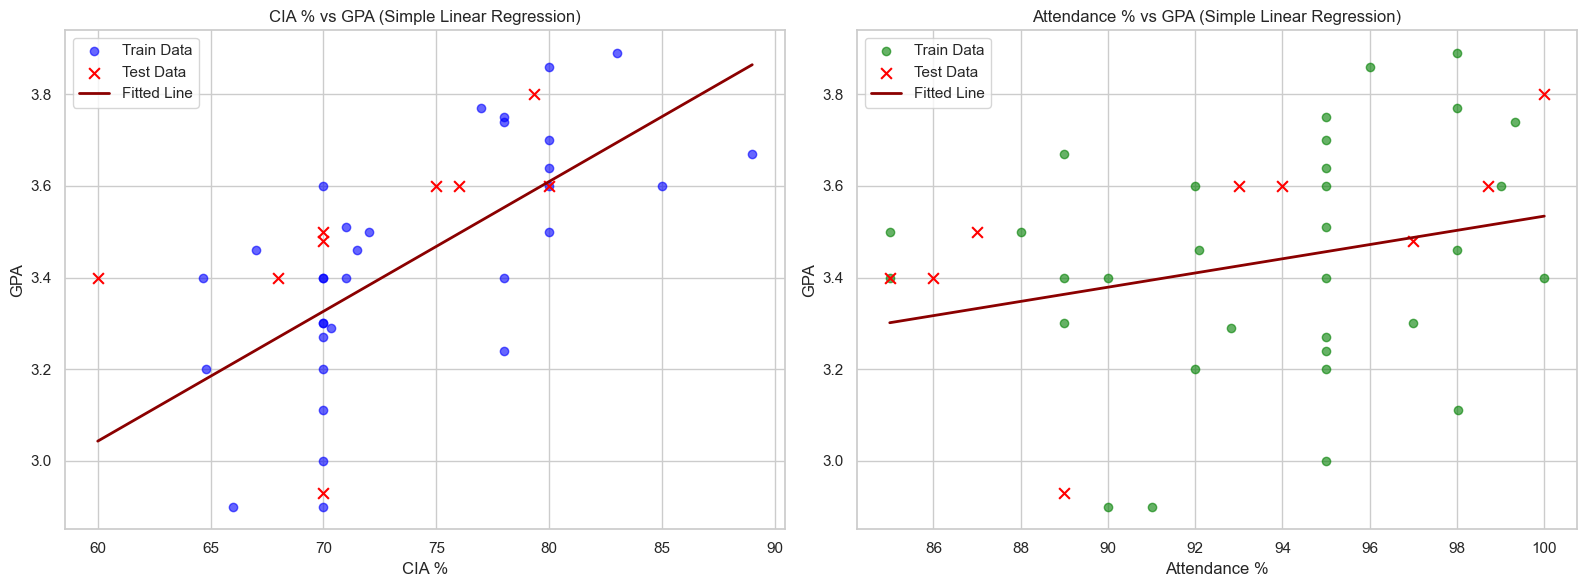

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_cia_train, y_train, color='blue', alpha=0.6, label='Train Data')
axes[0].scatter(X_cia_test, y_test, color='red', marker='x', s=60, label='Test Data')
x_range_cia = np.linspace(X_cia.min(), X_cia.max(), 100).reshape(-1, 1)
axes[0].plot(x_range_cia, model_cia.predict(x_range_cia), color='darkred', linewidth=2, label='Fitted Line')
axes[0].set_title('CIA % vs GPA (Simple Linear Regression)')
axes[0].set_xlabel('CIA %')
axes[0].set_ylabel('GPA')
axes[0].legend()

axes[1].scatter(X_att_train, y_train, color='green', alpha=0.6, label='Train Data')
axes[1].scatter(X_att_test, y_test, color='red', marker='x', s=60, label='Test Data')
x_range_att = np.linspace(X_att.min(), X_att.max(), 100).reshape(-1, 1)
axes[1].plot(x_range_att, model_att.predict(x_range_att), color='darkred', linewidth=2, label='Fitted Line')
axes[1].set_title('Attendance % vs GPA (Simple Linear Regression)')
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('GPA')
axes[1].legend()

plt.tight_layout()
plt.show()

Part C: Manual Computation using Ordinary Least Squares (OLS)


In [42]:
def manual_ols(X, y):
    X = X.flatten()
    N = len(X)
    sum_x = np.sum(X)
    sum_y = np.sum(y)
    sum_xy = np.sum(X * y)
    sum_x2 = np.sum(X ** 2)
    
    slope = (N * sum_xy - sum_x * sum_y) / (N * sum_x2 - sum_x ** 2)
    intercept = (sum_y - slope * sum_x) / N
    
    return slope, intercept

# Calculate manually
slope_cia_ols, intercept_cia_ols = manual_ols(X_cia_train, y_train)
slope_att_ols, intercept_att_ols = manual_ols(X_att_train, y_train)

print("CIA % vs GPA (Manual OLS)")
print(f"Slope (beta_1): {slope_cia_ols:.6f}")
print(f"Intercept (beta_0): {intercept_cia_ols:.6f}")
print(f"Regression Equation: GPA = {slope_cia_ols:.4f} * CIA% + {intercept_cia_ols:.4f}")

print("\nAttendance % vs GPA (Manual OLS)")
print(f"Slope (beta_1): {slope_att_ols:.6f}")
print(f"Intercept (beta_0): {intercept_att_ols:.6f}")
print(f"Regression Equation: GPA = {slope_att_ols:.4f} * Att% + {intercept_att_ols:.4f}")

CIA % vs GPA (Manual OLS)
Slope (beta_1): 0.028338
Intercept (beta_0): 1.342532
Regression Equation: GPA = 0.0283 * CIA% + 1.3425

Attendance % vs GPA (Manual OLS)
Slope (beta_1): 0.015515
Intercept (beta_0): 1.982574
Regression Equation: GPA = 0.0155 * Att% + 1.9826


Comparison and Validation Task:
We verify that the slope and intercept parameters from Scikit-learn and the manual OLS computation are mathematically identical, and compare predictions on the test set.

In [43]:
# Compute manual predictions
y_pred_cia_ols = slope_cia_ols * X_cia_test.flatten() + intercept_cia_ols
y_pred_att_ols = slope_att_ols * X_att_test.flatten() + intercept_att_ols

# Compile differences into a table for display
cia_compare_df = pd.DataFrame({
    'Actual GPA': y_test,
    'Sk-learn Pred': y_pred_cia_sk,
    'Manual OLS Pred': y_pred_cia_ols,
    'Absolute Difference': np.abs(y_pred_cia_sk - y_pred_cia_ols)
})

print("=== CIA vs GPA Prediction Comparison (Test Set) ===")
print(cia_compare_df.to_string(index=False))

# Verify parameter match
print("\n=== Slope & Intercept Validation ===")
print(f"CIA Model Slope Diff: {abs(slope_cia_sk - slope_cia_ols):.2e}")
print(f"CIA Model Intercept Diff: {abs(intercept_cia_sk - intercept_cia_ols):.2e}")
print(f"Att Model Slope Diff: {abs(slope_att_sk - slope_att_ols):.2e}")
print(f"Att Model Intercept Diff: {abs(intercept_att_sk - intercept_att_ols):.2e}")

=== CIA vs GPA Prediction Comparison (Test Set) ===
 Actual GPA  Sk-learn Pred  Manual OLS Pred  Absolute Difference
       3.60       3.467891         3.467891         4.440892e-16
       3.60       3.609582         3.609582         3.996803e-15
       3.48       3.326201         3.326201         2.664535e-15
       2.93       3.326201         3.326201         2.664535e-15
       3.40       3.269524         3.269524         4.440892e-15
       3.80       3.590595         3.590595         3.552714e-15
       3.40       3.042819         3.042819         9.769963e-15
       3.60       3.496229         3.496229         1.332268e-15
       3.50       3.326201         3.326201         2.664535e-15

=== Slope & Intercept Validation ===
CIA Model Slope Diff: 6.83e-16
CIA Model Intercept Diff: 5.06e-14
Att Model Slope Diff: 3.44e-15
Att Model Intercept Diff: 3.22e-13


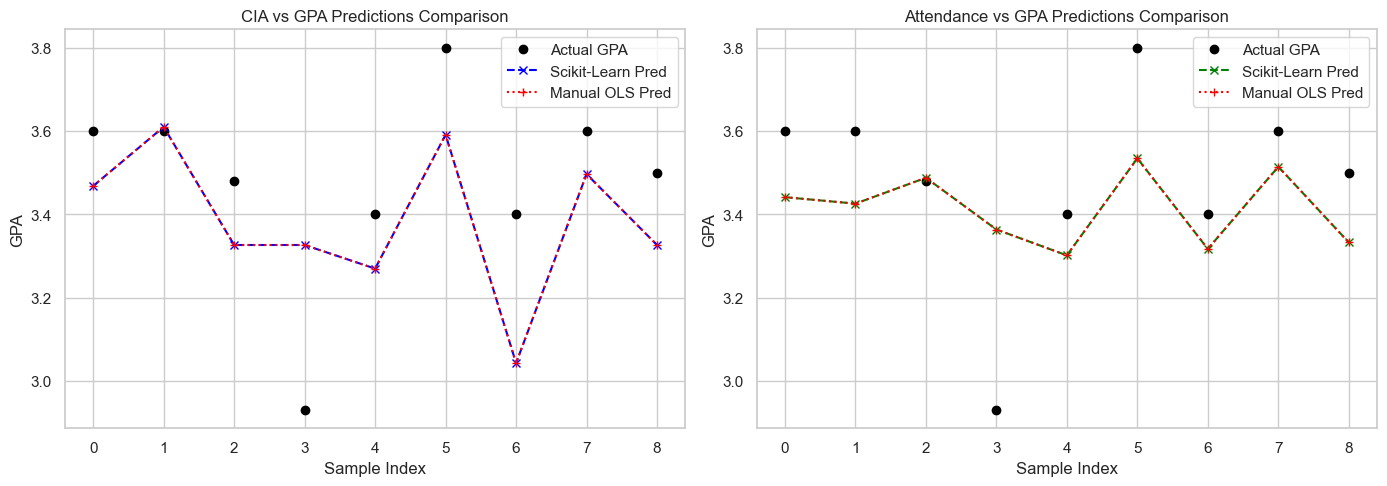

In [44]:
# Plot comparison of predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CIA Model Predictions Comparison
axes[0].plot(y_test, label='Actual GPA', marker='o', linestyle='', color='black')
axes[0].plot(y_pred_cia_sk, label='Scikit-Learn Pred', marker='x', linestyle='--', color='blue')
axes[0].plot(y_pred_cia_ols, label='Manual OLS Pred', marker='+', linestyle=':', color='red')
axes[0].set_title('CIA vs GPA Predictions Comparison')
axes[0].set_ylabel('GPA')
axes[0].set_xlabel('Sample Index')
axes[0].legend()

# Plot Attendance Model Predictions Comparison
axes[1].plot(y_test, label='Actual GPA', marker='o', linestyle='', color='black')
axes[1].plot(y_pred_att_sk, label='Scikit-Learn Pred', marker='x', linestyle='--', color='green')
axes[1].plot(y_pred_att_ols, label='Manual OLS Pred', marker='+', linestyle=':', color='red')
axes[1].set_title('Attendance vs GPA Predictions Comparison')
axes[1].set_ylabel('GPA')
axes[1].set_xlabel('Sample Index')
axes[1].legend()

plt.tight_layout()
plt.show()

Diagnostic Plots: Residual Analysis
Residual analysis is critical to check OLS regression assumptions. The residuals (errors) should ideally be normally distributed and exhibit homoscedasticity (constant variance).
We calculate residuals for both models: Residual= y(actual) - y(pred)

c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


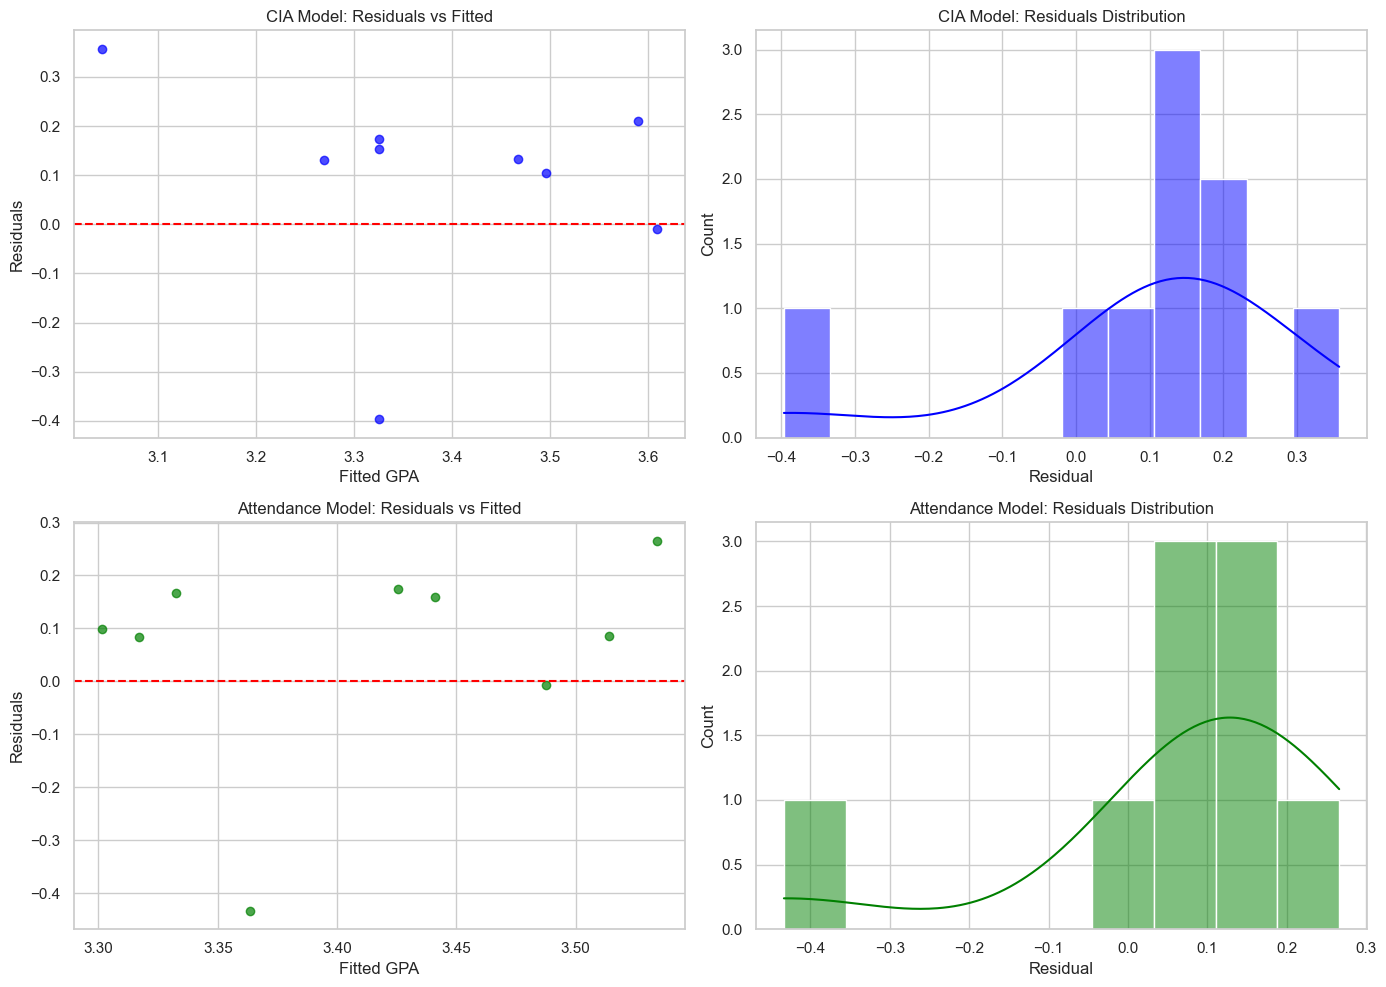

In [45]:
residuals_cia = y_test - y_pred_cia_sk
residuals_att = y_test - y_pred_att_sk

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CIA Residuals vs Fitted values
axes[0, 0].scatter(y_pred_cia_sk, residuals_cia, color='blue', alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('CIA Model: Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted GPA')
axes[0, 0].set_ylabel('Residuals')

# CIA Residuals Distribution
sns.histplot(residuals_cia, kde=True, color='blue', ax=axes[0, 1])
axes[0, 1].set_title('CIA Model: Residuals Distribution')
axes[0, 1].set_xlabel('Residual')

# Attendance Residuals vs Fitted values
axes[1, 0].scatter(y_pred_att_sk, residuals_att, color='green', alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Attendance Model: Residuals vs Fitted')
axes[1, 0].set_xlabel('Fitted GPA')
axes[1, 0].set_ylabel('Residuals')

# Attendance Residuals Distribution
sns.histplot(residuals_att, kde=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title('Attendance Model: Residuals Distribution')
axes[1, 1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

Inference: Regression & Comparison Analysis

- Scikit-Learn vs. Manual OLS Validation: The slope and intercept values obtained from Scikit-Learn and Manual Ordinary Least Squares (OLS) were identical up to floating-point precision (differences close to 10⁻¹⁶). This confirms the correctness of the manual implementation and verifies that Scikit-Learn uses the OLS method for fitting a linear regression model.

- Experiment 1 (CIA Percentage vs. GPA): The regression equation obtained was:

  GPA = 0.0283 × CIA Percentage + 1.3425

  The positive slope indicates that students with higher CIA percentages tend to have higher GPAs. However, the coefficient of determination (R² = 0.073) shows that CIA percentage explains only about 7.3% of the variation in GPA. Therefore, CIA alone is a weak predictor of academic performance in this dataset.

- Experiment 2 (Attendance Percentage vs. GPA): The regression equation obtained was:

  GPA = 0.0155 × Attendance Percentage + 1.9826

  The positive slope indicates that higher attendance is associated with higher GPA. The coefficient of determination (R² = 0.205) shows that attendance explains approximately 20.5% of the variation in GPA, making it a stronger predictor than CIA percentage.

- Overall Comparison: Both CIA Percentage and Attendance Percentage have a positive relationship with GPA. Among the two variables, Attendance Percentage demonstrates a stronger influence on GPA because it achieves a higher R² value. Nevertheless, the relatively low R² values for both models suggest that other factors such as technical competencies, extracurricular involvement, internships, study habits, and personal learning ability may also significantly influence GPA.

Parameter Saving Task

In [46]:
params = {
    'cia_slope': slope_cia_sk,
    'cia_intercept': intercept_cia_sk,
    'att_slope': slope_att_sk,
    'att_intercept': intercept_att_sk
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print("Model parameters successfully saved to 'linear_regression_weights.pkl'")
print("Saved parameters:", params)

Model parameters successfully saved to 'linear_regression_weights.pkl'
Saved parameters: {'cia_slope': 0.028338125550439658, 'cia_intercept': 1.3425318720269384, 'att_slope': 0.015514827537474093, 'att_intercept': 1.9825736887255485}


Parameter Loading and Inference Demonstration


In [47]:
# Load weights
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Successfully loaded parameters from pickle file:")
print(loaded_params)

# Function to predict GPA using loaded parameters
def predict_gpa(cia_percent=None, att_percent=None):
    predictions = {}
    if cia_percent is not None:
        pred_gpa_cia = loaded_params['cia_slope'] * cia_percent + loaded_params['cia_intercept']
        # Cap at 4.0 GPA
        pred_gpa_cia = min(4.0, max(0.0, pred_gpa_cia))
        predictions['Predicted GPA from CIA'] = round(pred_gpa_cia, 2)
    if att_percent is not None:
        pred_gpa_att = loaded_params['att_slope'] * att_percent + loaded_params['att_intercept']
        # Cap at 4.0 GPA
        pred_gpa_att = min(4.0, max(0.0, pred_gpa_att))
        predictions['Predicted GPA from Attendance'] = round(pred_gpa_att, 2)
    return predictions

# Test prediction with new hypothetical student values
new_student_cia = 85.0
new_student_att = 95.0
predictions = predict_gpa(new_student_cia, new_student_att)

print(f"\nPredictions for new student (CIA={new_student_cia}%, Attendance={new_student_att}%):")
for model, pred in predictions.items():
    print(f"- {model}: {pred}")

Successfully loaded parameters from pickle file:
{'cia_slope': 0.028338125550439658, 'cia_intercept': 1.3425318720269384, 'att_slope': 0.015514827537474093, 'att_intercept': 1.9825736887255485}

Predictions for new student (CIA=85.0%, Attendance=95.0%):
- Predicted GPA from CIA: 3.75
- Predicted GPA from Attendance: 3.46


Final Observations

1. Simple Linear Regression was successfully implemented using both Scikit-Learn and Manual OLS methods.

2. The regression models showed a positive relationship between CIA Percentage, Attendance Percentage, and GPA. Students with higher CIA scores and attendance generally tended to have higher GPAs.

3. Attendance Percentage produced a higher R² value (0.205) than CIA Percentage (0.073), indicating that attendance was a stronger predictor of GPA in this dataset.

4. The slope and intercept values obtained using Scikit-Learn and Manual OLS were identical up to floating-point precision, validating the correctness of the implementation.

5. The trained model parameters were successfully stored and retrieved using a Pickle file, and the saved parameters were used to generate GPA predictions for new input values.

6. The relatively low R² values suggest that GPA is influenced by additional factors beyond CIA and Attendance, and therefore a single-variable linear model provides only a limited explanation of student performance.